# Event/background QC figure workflow

This notebook is a cleaned-up, figure-oriented version of the event/background analysis discussed in the video meeting. It focuses on one question: for each ROI, do detected events look like clear calcium transients relative to that ROI's own background, and how does that vary across plane, depth, ROI size, and classifier outputs when available?

The workflow keeps the analysis compact: it saves one row per ROI plus one row per merged event cluster. It does **not** save full per-ROI dF/F traces in the output tables; traces are loaded from the materialized session cache only when plotting or reviewing an example ROI.

## Setup

`SESSION_DIR` should point to a materialized session cache, preferably in scratch/project storage on PACE. `OUTPUT_DIR` stores compact CSV summaries and generated figures. The default session is the one used for the current mesoscope QC viewer.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import plotly.graph_objects as go
    import plotly.express as px
except Exception:
    go = None
    px = None

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src").exists():
    REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from scripts.generate_event_background_figure_qc import build_figure_metrics, available_planes, load_plane_arrays
from src.mesoscope_snr import _event_onsets, _merged_event_clusters

SESSION_DIR = Path("/storage/scratch1/3/grubin6/openscope_ophys_qc_materialized/multiplane-ophys_839909_2026-02-20_12-53-27")
NWB_SOURCE = Path("/storage/scratch1/3/grubin6/openscope_ophys_qc_dandi_downloads/sub-839909_ses-multiplane-ophys-839909-2026-02-20-12-53-27_ophys.nwb")
OUTPUT_DIR = REPO_ROOT / "outputs" / "background_event_qc"
HTML_OUTPUT = REPO_ROOT / "outputs" / "html_viewers" / "multiplane-ophys_839909_event_background_figure_review.html"

BASE_METRICS_CSV = OUTPUT_DIR / f"{SESSION_DIR.name}_roi_metrics_with_nonlong_event_composition.csv"
BASE_CLUSTER_CSV = OUTPUT_DIR / f"{SESSION_DIR.name}_event_clusters_with_amplitude_classes.csv"
MAX_FRAMES = None
PLANES = available_planes(SESSION_DIR)

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
PLANES

['VISl_4',
 'VISl_5',
 'VISl_6',
 'VISl_7',
 'VISp_0',
 'VISp_1',
 'VISp_2',
 'VISp_3']

## Metric definitions from the meeting

**Raw events** are event samples already detected in the Allen event trace. They are treated as candidate inferred activity times, not as ground-truth spike times.

**Merged event clusters** are created by merging raw event onsets that occur within `0.5 s` of each other. The cluster midpoint is used only to define a broad event/non-event window and to measure local amplitude. This intentionally gives up temporal precision because the goal here is background-vs-event partitioning and ROI quality assessment, not exact spike timing.

**Event windows** are `0.5 s` before and `2.0 s` after the merged midpoint. Samples outside all event windows are treated as background/non-event samples.

**Background noise** is the robust MAD estimate from those non-event dF/F samples:

$\sigma_{background}=1.4826\,median(|x - median(x)|)$

**Detector-first event size** is the peak dF/F after each merged midpoint minus a local pre-event baseline, divided by that ROI's background noise. Events are binned as `<2 SD`, `2-4 SD`, `>4 SD`, or `>=3 s long`. Long windows are flagged separately and excluded from the three-way event-composition clustering.

**Trace-threshold comparison** is the meeting suggestion from the opposite direction: estimate a low-percentile baseline from the dF/F trace first, estimate robust noise from low/typical trace samples, then detect dF/F excursions above `baseline + 2 SD` without using the Allen event trace. Agreement/disagreement with the Allen-event-based metric is used as a sanity check.

In [2]:
metrics_csv, clusters_csv = build_figure_metrics(
    SESSION_DIR,
    OUTPUT_DIR,
    metrics_csv=BASE_METRICS_CSV if BASE_METRICS_CSV.exists() else None,
    cluster_csv=BASE_CLUSTER_CSV if BASE_CLUSTER_CSV.exists() else None,
    nwb_source=NWB_SOURCE if NWB_SOURCE.exists() else None,
    planes=PLANES,
    max_frames=MAX_FRAMES,
)
roi_metrics = pd.read_csv(metrics_csv)
event_clusters = pd.read_csv(clusters_csv) if clusters_csv.exists() else pd.DataFrame()
print(metrics_csv)
print(clusters_csv)
print(f"ROI rows: {len(roi_metrics):,}; event-cluster rows: {len(event_clusters):,}")
roi_metrics.head()

[INFO] trace-threshold metrics for VISl_4


[INFO] trace-threshold metrics for VISl_5


[INFO] trace-threshold metrics for VISl_6


[INFO] trace-threshold metrics for VISl_7


[INFO] trace-threshold metrics for VISp_0


[INFO] trace-threshold metrics for VISp_1


[INFO] trace-threshold metrics for VISp_2


[INFO] trace-threshold metrics for VISp_3


/storage/home/hcoda1/3/grubin6/openscope-ophys-qc/outputs/background_event_qc/multiplane-ophys_839909_2026-02-20_12-53-27_figure_event_qc_metrics.csv
/storage/home/hcoda1/3/grubin6/openscope-ophys-qc/outputs/background_event_qc/multiplane-ophys_839909_2026-02-20_12-53-27_figure_event_clusters.csv
ROI rows: 1,810; event-cluster rows: 511,318


,session_dir,session,plane,roi_index,n_timepoints,n_finite_timepoints,fraction_nan,robust_event_snr,robust_event_signal_amp,robust_event_noise_sd,...,event_cluster_count_flag,max_event_cluster_span_s_flag,p95_event_cluster_span_s_flag,max_raw_onsets_in_cluster_flag,n_warning_long_event_clusters_flag,has_warning_long_event_cluster_flag,n_severe_long_event_clusters_flag,has_severe_long_event_cluster_flag,n_extreme_long_event_clusters_flag,has_extreme_long_event_cluster_flag
0,/storage/scratch1/3/grubin6/openscope_ophys_qc...,multiplane-ophys_839909_2026-02-20_12-53-27,VISl_4,0,10000,10000,0.0,1.936100,0.205288,0.106032,...,269.0,1.30788,0.467100,5.0,0.0,False,0.0,False,0.0,False
1,/storage/scratch1/3/grubin6/openscope_ophys_qc...,multiplane-ophys_839909_2026-02-20_12-53-27,VISl_4,1,10000,10000,0.0,3.402822,0.215190,0.063239,...,226.0,1.30788,0.467100,4.0,0.0,False,0.0,False,0.0,False
2,/storage/scratch1/3/grubin6/openscope_ophys_qc...,multiplane-ophys_839909_2026-02-20_12-53-27,VISl_4,2,10000,10000,0.0,2.244994,0.189742,0.084518,...,549.0,2.98944,1.177092,10.0,0.0,False,0.0,False,0.0,False
3,/storage/scratch1/3/grubin6/openscope_ophys_qc...,multiplane-ophys_839909_2026-02-20_12-53-27,VISl_4,3,10000,10000,0.0,2.059020,0.144355,0.070108,...,306.0,1.68156,0.467100,5.0,0.0,False,0.0,False,0.0,False
4,/storage/scratch1/3/grubin6/openscope_ophys_qc...,multiplane-ophys_839909_2026-02-20_12-53-27,VISl_4,4,10000,10000,0.0,2.203539,0.699469,0.317430,...,66.0,1.58814,0.256905,5.0,0.0,False,0.0,False,0.0,False


## Plane metadata and depth

Plane numbers are not interpreted as physical depth. When `plane_metadata.csv` exists, plots use the official `depth_um`. This matters because superficial planes can contain more dendritic/layer-1 signal, while deeper planes can lose signal quality from background and scattering. Both effects can change the event-composition metric.

In [3]:
def load_plane_metadata(session_dir):
    path = session_dir / "plane_metadata.csv"
    if path.exists():
        return pd.read_csv(path)
    rows = []
    for plane in PLANES:
        region = plane.rsplit("_", 1)[0] if "_" in plane else plane
        rows.append({"plane": plane, "structure": region, "depth_um": np.nan})
    return pd.DataFrame(rows)

plane_meta = load_plane_metadata(SESSION_DIR)
if "structure" not in plane_meta.columns:
    plane_meta["structure"] = plane_meta["plane"].astype(str).str.replace(r"_\d+$", "", regex=True)
roi_metrics_meta = roi_metrics.merge(plane_meta[[c for c in ["plane", "structure", "depth_um"] if c in plane_meta.columns]], on="plane", how="left")
display(plane_meta.sort_values(["structure", "depth_um", "plane"]))

,plane,structure,depth_um
0,VISl_4,VISl,NaN
1,VISl_5,VISl,NaN
2,VISl_6,VISl,NaN
3,VISl_7,VISl,NaN
4,VISp_0,VISp,NaN
5,VISp_1,VISp,NaN
6,VISp_2,VISp,NaN
7,VISp_3,VISp,NaN


## Event-window examples

These examples make the algorithm visually explicit. Red vertical lines are raw Allen event onsets. Orange shaded windows are merged event windows, and orange vertical lines are the midpoint used for amplitude/background calculations. Long windows are not treated as ordinary transients; they are flagged for manual inspection.

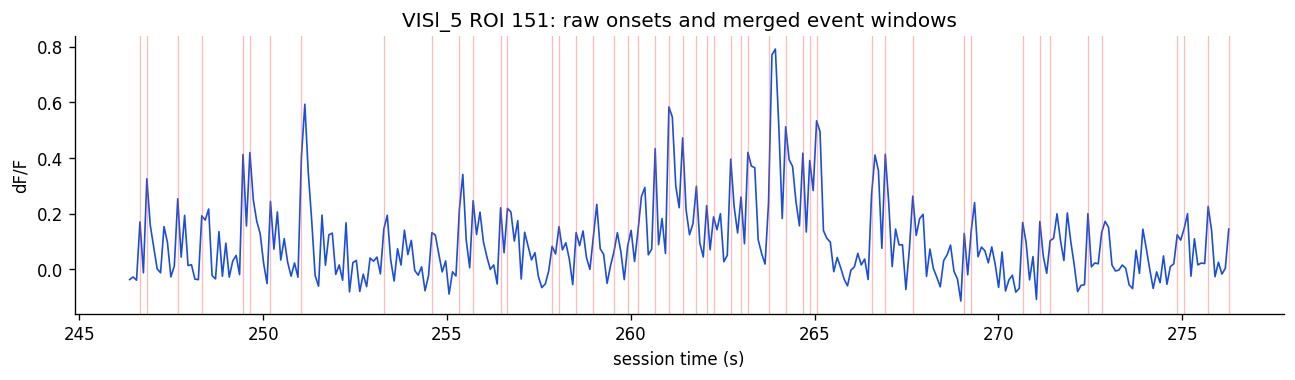

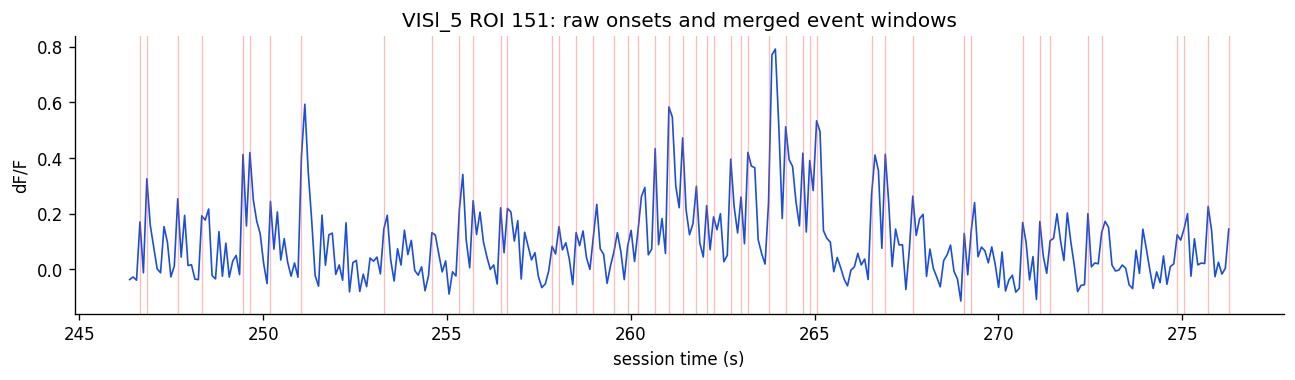

In [4]:
def plot_event_window_example(plane=None, roi_index=None, start_s=None, span_s=30):
    if event_clusters.empty:
        print("No event cluster table available.")
        return None
    if plane is None or roi_index is None:
        candidates = event_clusters.sort_values("cluster_span_s", ascending=False).head(100)
        if candidates.empty:
            return None
        row = candidates.sample(1, random_state=3).iloc[0]
        plane, roi_index = row["plane"], int(row["roi_index"])
        if start_s is None:
            start_s = max(0, float(row["midpoint_s"]) - span_s / 2)
    dff, events, ts = load_plane_arrays(SESSION_DIR, plane, max_frames=MAX_FRAMES)
    frame_rate = 1 / np.nanmedian(np.diff(ts))
    if start_s is None:
        start_s = 0
    end_s = start_s + span_s
    lo = int(np.searchsorted(ts, start_s, side="left"))
    hi = int(np.searchsorted(ts, end_s, side="right"))
    tr = dff[lo:hi, roi_index]
    fig, ax = plt.subplots(figsize=(13, 3))
    ax.plot(ts[lo:hi], tr, color="#1d4ed8", lw=1.0)
    ev = events[:, roi_index] if events is not None else None
    if ev is not None:
        onsets = _event_onsets(ev, 0.0)
        for idx in onsets[(onsets >= lo) & (onsets < hi)]:
            ax.axvline(ts[idx], color="#ef4444", alpha=0.35, lw=0.8)
    rows = event_clusters[(event_clusters["plane"] == plane) & (event_clusters["roi_index"] == roi_index)]
    for _, cl in rows.iterrows():
        a, b, mid = cl.get("evaluation_start_s"), cl.get("evaluation_end_s"), cl.get("midpoint_s")
        if pd.isna(a) or pd.isna(b) or b < start_s or a > end_s:
            continue
        ax.axvspan(max(a, start_s), min(b, end_s), color="#fb923c", alpha=0.16)
        ax.axvline(mid, color="#f97316", lw=1.1)
    ax.set_title(f"{plane} ROI {roi_index}: raw onsets and merged event windows")
    ax.set_xlabel("session time (s)")
    ax.set_ylabel("dF/F")
    return fig

plot_event_window_example()

## Population distribution of event sizes

This is the population-level version requested in the meeting. Instead of only showing one ROI's event-size histogram, each point/entry summarizes one ROI by the median amplitude of its merged detected events in units of that ROI's background noise.

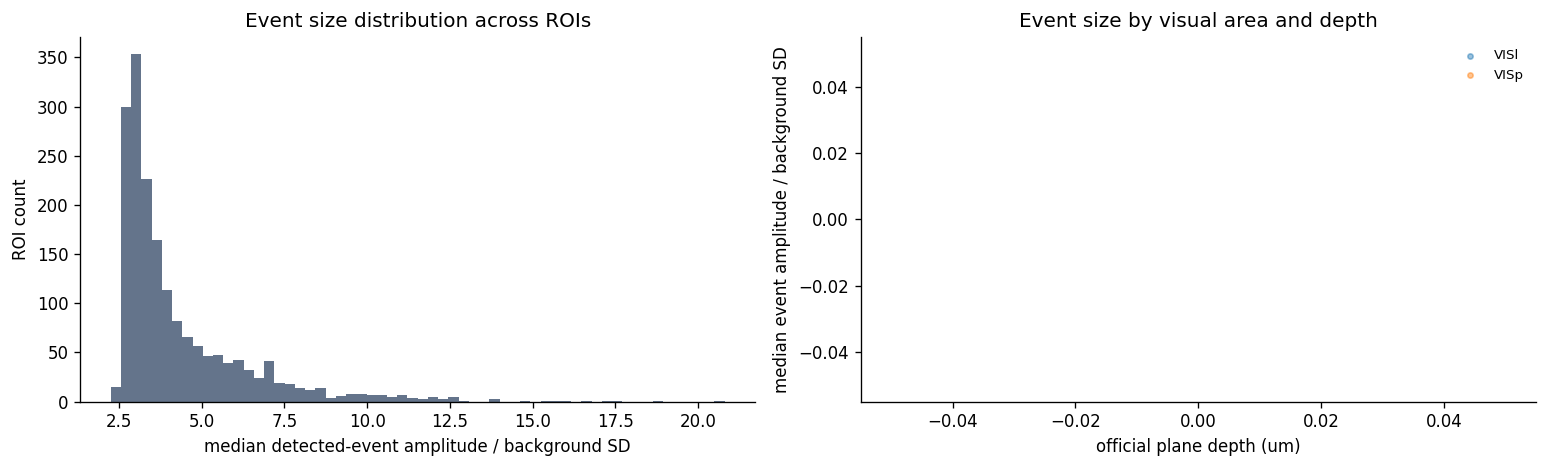

In [5]:
metric = "background_event_median_amp_noise_units"
plot_df = roi_metrics_meta.dropna(subset=[metric]).copy()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(plot_df[metric], bins=60, color="#64748b")
axes[0].set_xlabel("median detected-event amplitude / background SD")
axes[0].set_ylabel("ROI count")
axes[0].set_title("Event size distribution across ROIs")
if "depth_um" in plot_df:
    for structure, sub in plot_df.groupby("structure", dropna=False):
        axes[1].scatter(sub["depth_um"], sub[metric], s=10, alpha=0.45, label=str(structure))
    axes[1].set_xlabel("official plane depth (um)")
    axes[1].set_ylabel("median event amplitude / background SD")
    axes[1].legend(frameon=False, fontsize=8)
axes[1].set_title("Event size by visual area and depth")
plt.tight_layout()

## Event-type proportions by region and depth

Each ROI contributes proportions of non-long event clusters in the `<2 SD`, `2-4 SD`, and `>4 SD` bins. Long `>=3 s` clusters are shown separately because those windows may represent sustained activity, baseline shifts, or repeated deconvolution detections rather than one isolated transient.

,structure,depth_um,plane,nonlong_event_fraction_lt_2sd,nonlong_event_fraction_2_4sd,nonlong_event_fraction_gt_4sd,long_gt_3s_fraction_all_clusters
0,VISl,NaN,VISl_4,0.051841,0.333824,0.614334,0.000156
1,VISl,NaN,VISl_5,0.095629,0.462004,0.442367,0.000531
2,VISl,NaN,VISl_6,0.089409,0.615959,0.294632,0.000354
3,VISl,NaN,VISl_7,0.119812,0.638809,0.241379,0.000127
4,VISp,NaN,VISp_0,0.049524,0.345474,0.605002,0.000108
5,VISp,NaN,VISp_1,0.105357,0.536312,0.358331,0.000592
6,VISp,NaN,VISp_2,0.082707,0.602507,0.314786,0.000123
7,VISp,NaN,VISp_3,0.123905,0.639995,0.236100,0.000283


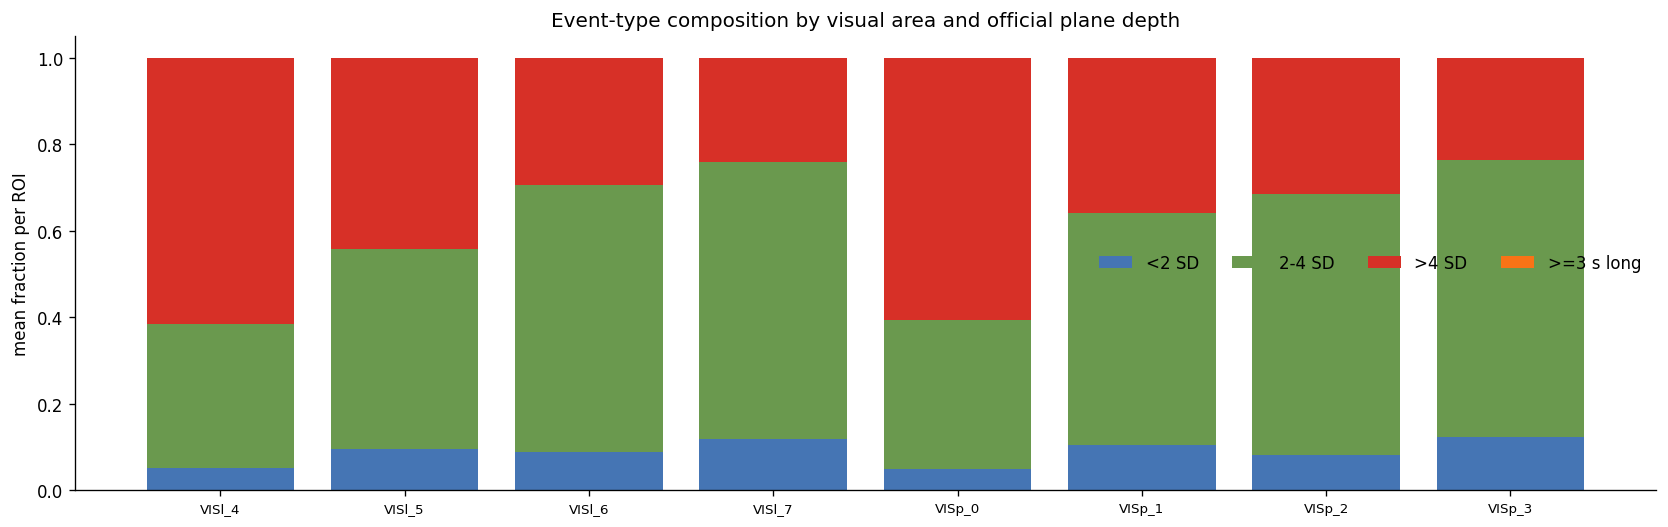

In [6]:
prop_cols = ["nonlong_event_fraction_lt_2sd", "nonlong_event_fraction_2_4sd", "nonlong_event_fraction_gt_4sd", "long_gt_3s_fraction_all_clusters"]
labels = ["<2 SD", "2-4 SD", ">4 SD", ">=3 s long"]
colors = ["#4575b4", "#6a994e", "#d73027", "#f97316"]
summary = roi_metrics_meta.groupby(["structure", "depth_um", "plane"], dropna=False)[prop_cols].mean().reset_index()
summary = summary.sort_values(["structure", "depth_um", "plane"])
fig, ax = plt.subplots(figsize=(14, 4.5))
x = np.arange(len(summary))
bottom = np.zeros(len(summary))
for col, label, color in zip(prop_cols, labels, colors):
    vals = summary[col].fillna(0).to_numpy()
    ax.bar(x, vals, bottom=bottom, label=label, color=color)
    bottom += vals
ax.set_xticks(x)
ax.set_xticklabels([f"{r.plane}\n{r.structure}\n{r.depth_um:.0f} um" if pd.notna(r.depth_um) else str(r.plane) for r in summary.itertuples()], rotation=0, fontsize=8)
ax.set_ylabel("mean fraction per ROI")
ax.set_title("Event-type composition by visual area and official plane depth")
ax.legend(frameon=False, ncol=4)
plt.tight_layout()
display(summary)

## Background-first comparison

The detector-first metric starts from Allen events and then asks how far those events sit above background. The trace-threshold metric starts from the dF/F trace itself, estimates a low-percentile background, and detects threshold crossings independent of Allen event calls. ROIs where these disagree are useful failure-mode examples: they may have baseline shifts, tonic activity, missed events, or spurious deconvolution detections.

,plane,roi_index,structure,depth_um,background_event_fraction_gt_4sd,trace_event_fraction_gt_4sd,event_definition_disagreement
1572,VISp_2,47,VISp,NaN,0.000000,0.958333,0.958333
1543,VISp_2,18,VISp,NaN,0.000000,0.957265,0.957265
1693,VISp_3,84,VISp,NaN,0.000000,0.956204,0.956204
1738,VISp_3,129,VISp,NaN,0.029412,0.982143,0.952731
631,VISl_6,45,VISl,NaN,0.000000,0.951613,0.951613
1729,VISp_3,120,VISp,NaN,0.000000,0.946565,0.946565
698,VISl_7,36,VISl,NaN,0.060241,0.990991,0.930750
787,VISl_7,125,VISl,NaN,0.020000,0.948454,0.928454
1631,VISp_3,22,VISp,NaN,0.031579,0.957265,0.925686
553,VISl_5,202,VISl,NaN,0.029412,0.951923,0.922511


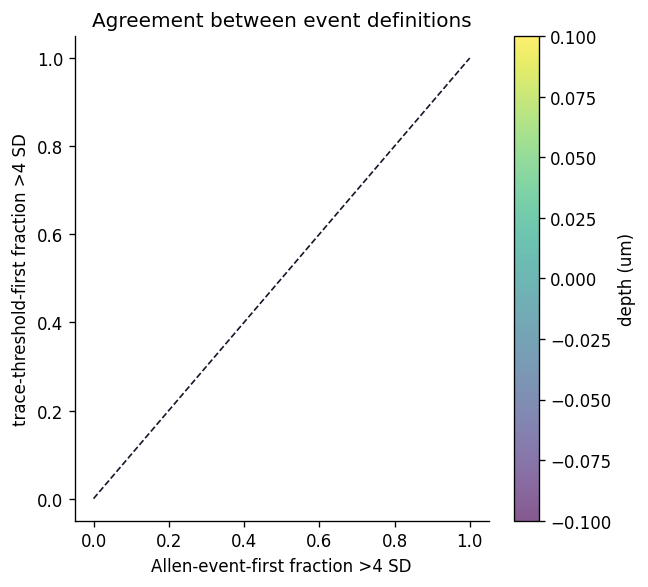

In [7]:
xcol = "background_event_fraction_gt_4sd"
ycol = "trace_event_fraction_gt_4sd"
plot_df = roi_metrics_meta.dropna(subset=[xcol, ycol]).copy()
fig, ax = plt.subplots(figsize=(5.5, 5))
if len(plot_df):
    sc = ax.scatter(plot_df[xcol], plot_df[ycol], c=plot_df.get("depth_um", pd.Series(np.nan, index=plot_df.index)), s=16, alpha=0.65, cmap="viridis")
    ax.plot([0, 1], [0, 1], color="#111827", lw=1, ls="--")
    ax.set_xlabel("Allen-event-first fraction >4 SD")
    ax.set_ylabel("trace-threshold-first fraction >4 SD")
    ax.set_title("Agreement between event definitions")
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("depth (um)")
plt.tight_layout()

if len(plot_df):
    plot_df["event_definition_disagreement"] = (plot_df[xcol] - plot_df[ycol]).abs()
    display(plot_df.sort_values("event_definition_disagreement", ascending=False)[["plane", "roi_index", "structure", "depth_um", xcol, ycol, "event_definition_disagreement"]].head(12))

## ROI size and classifier context

When cached ROI masks/classifier outputs are available, this section checks whether event quality tracks ROI area or soma/dendrite probability. If these columns are missing, regenerate the materialized cache with ROI mask metadata included, or point this notebook to a cache that already contains `pixel_masks.npz` / `roi_metadata.csv`.

available context columns: ['roi_area_pixels', 'soma_probability', 'dendrite_probability', 'roi_classifier_confidence']


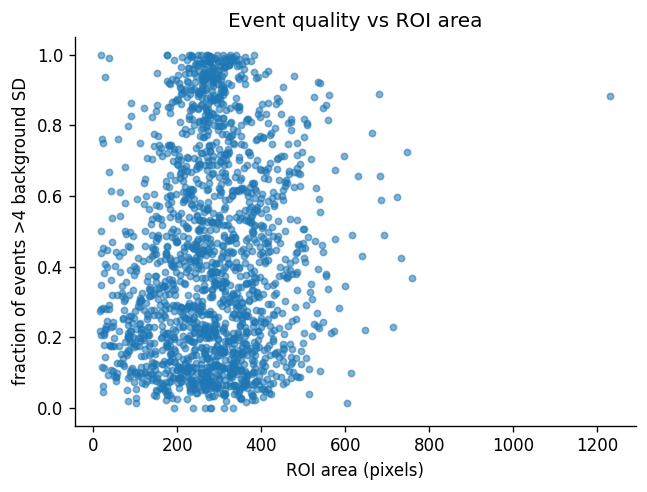

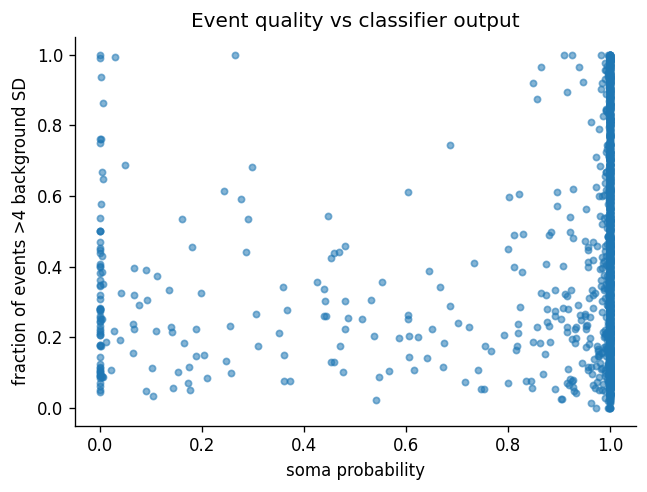

In [8]:
context_cols = [col for col in ["roi_area_pixels", "soma_probability", "dendrite_probability", "roi_classifier_confidence"] if col in roi_metrics_meta.columns]
print("available context columns:", context_cols)
if "roi_area_pixels" in context_cols:
    fig, ax = plt.subplots(figsize=(5.5, 4.2))
    ax.scatter(roi_metrics_meta["roi_area_pixels"], roi_metrics_meta["background_event_fraction_gt_4sd"], s=14, alpha=0.55)
    ax.set_xlabel("ROI area (pixels)")
    ax.set_ylabel("fraction of events >4 background SD")
    ax.set_title("Event quality vs ROI area")
    plt.tight_layout()
else:
    print("ROI area was not available in this materialized cache.")

if "soma_probability" in context_cols:
    fig, ax = plt.subplots(figsize=(5.5, 4.2))
    ax.scatter(roi_metrics_meta["soma_probability"], roi_metrics_meta["background_event_fraction_gt_4sd"], s=14, alpha=0.55)
    ax.set_xlabel("soma probability")
    ax.set_ylabel("fraction of events >4 background SD")
    ax.set_title("Event quality vs classifier output")
    plt.tight_layout()
else:
    print("Soma/dendrite classifier outputs were not available in this materialized cache.")

## Interactive event-composition space

The 3D plot places each ROI in a space defined by its event-type proportions: `<2 SD`, `2-4 SD`, and `>4 SD`. Points are colored by the k-means event-composition class. This is the static notebook version of the supplementary HTML viewer.

In [9]:
plot_df = roi_metrics_meta.dropna(subset=["nonlong_event_fraction_lt_2sd", "nonlong_event_fraction_2_4sd", "nonlong_event_fraction_gt_4sd"]).copy()
if go is not None and len(plot_df):
    fig = px.scatter_3d(
        plot_df,
        x="nonlong_event_fraction_lt_2sd",
        y="nonlong_event_fraction_2_4sd",
        z="nonlong_event_fraction_gt_4sd",
        color="event_composition_label",
        hover_data=["plane", "roi_index", "structure", "depth_um", "background_event_median_amp_noise_units", "trace_event_fraction_gt_4sd"],
        labels={
            "nonlong_event_fraction_lt_2sd": "fraction <2 SD",
            "nonlong_event_fraction_2_4sd": "fraction 2-4 SD",
            "nonlong_event_fraction_gt_4sd": "fraction >4 SD",
        },
        height=650,
    )
    fig.update_traces(marker={"size": 3})
    fig.show()
else:
    print("Plotly is unavailable or no composition rows exist.")

Plotly is unavailable or no composition rows exist.


## Interactive ROI trace retrieval

Use this cell to inspect a specific ROI from any table above. The trace is fully zoomable in notebook outputs when Plotly is available. Red lines mark raw Allen event onsets; orange bands mark merged event windows and orange lines mark merged midpoints.

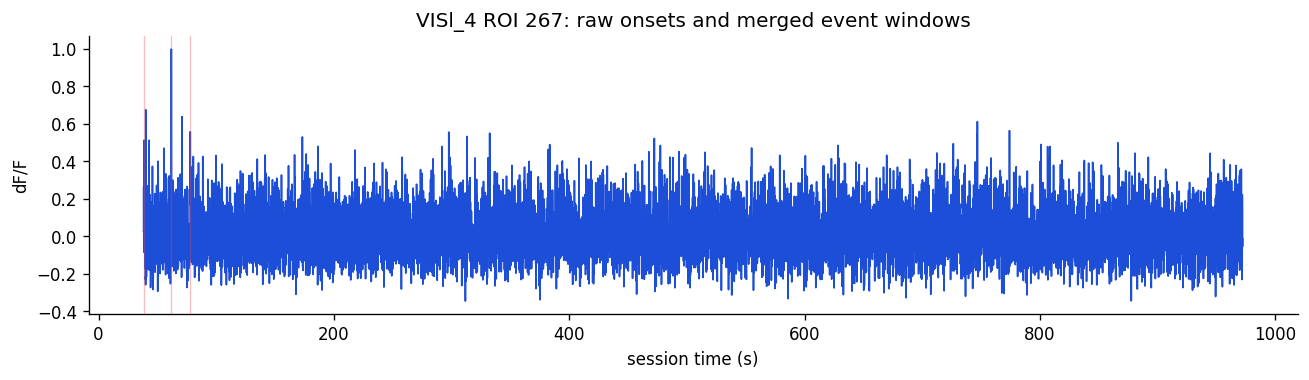

In [10]:
ROI_TO_RETRIEVE_PLANE = None  # e.g. "VISp_0"
ROI_TO_RETRIEVE_INDEX = None  # e.g. 42
ROI_TRACE_START_S = None
ROI_TRACE_END_S = None


def show_interactive_roi_trace(plane, roi_index, start_s=None, end_s=None):
    dff, events, ts = load_plane_arrays(SESSION_DIR, plane, max_frames=MAX_FRAMES)
    tr = dff[:, int(roi_index)]
    if start_s is None:
        start_s = float(ts[0])
    if end_s is None:
        end_s = float(ts[-1])
    mask = (ts >= start_s) & (ts <= end_s)
    if go is None:
        return plot_event_window_example(plane, int(roi_index), start_s=start_s, span_s=end_s-start_s)
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=ts[mask], y=tr[mask], mode="lines", name="dF/F", line={"color": "#1d4ed8", "width": 1}))
    if events is not None:
        onsets = _event_onsets(events[:, int(roi_index)], 0.0)
        for idx in onsets[(ts[onsets] >= start_s) & (ts[onsets] <= end_s)]:
            fig.add_vline(x=float(ts[idx]), line_color="#ef4444", line_width=1, opacity=0.35)
    rows = event_clusters[(event_clusters["plane"] == plane) & (event_clusters["roi_index"] == int(roi_index))]
    for _, cl in rows.iterrows():
        a, b, mid = cl.get("evaluation_start_s"), cl.get("evaluation_end_s"), cl.get("midpoint_s")
        if pd.isna(a) or pd.isna(b) or b < start_s or a > end_s:
            continue
        fig.add_vrect(x0=max(float(a), start_s), x1=min(float(b), end_s), fillcolor="#fb923c", opacity=0.13, line_width=0)
        fig.add_vline(x=float(mid), line_color="#f97316", line_width=1)
    fig.update_layout(
        title=f"{plane} ROI {roi_index}: dF/F with raw events and merged event windows",
        xaxis_title="session time (s)",
        yaxis_title="dF/F",
        height=420,
        margin={"l": 50, "r": 20, "t": 55, "b": 45},
    )
    fig.show()

if ROI_TO_RETRIEVE_PLANE is None or ROI_TO_RETRIEVE_INDEX is None:
    example = roi_metrics_meta.sort_values("background_event_fraction_gt_4sd", ascending=False).iloc[0]
    show_interactive_roi_trace(example["plane"], int(example["roi_index"]), ROI_TRACE_START_S, ROI_TRACE_END_S)
else:
    show_interactive_roi_trace(ROI_TO_RETRIEVE_PLANE, ROI_TO_RETRIEVE_INDEX, ROI_TRACE_START_S, ROI_TRACE_END_S)

## Supplementary HTML viewer

Run this cell to regenerate the standalone viewer. It requires a materialized cache with functional projections and sparse ROI masks. If the current cache only contains dF/F and events, the notebook will keep going and report what is missing.

In [11]:
from scripts.create_event_cluster_review_html import create_event_cluster_review_html

try:
    out = create_event_cluster_review_html(
        SESSION_DIR,
        metrics_csv,
        HTML_OUTPUT,
        clusters_csv=clusters_csv,
        max_frames=MAX_FRAMES,
    )
    print(out)
except FileNotFoundError as exc:
    print(f"Could not regenerate full FOV-overlay HTML from this cache: {exc}")
    existing = REPO_ROOT / "outputs" / "html_viewers" / "multiplane-ophys_839909_event_cluster_review.html"
    if existing.exists():
        print(f"Existing viewer still available: {existing}")

[INFO] embedding VISl_4


[INFO] embedding VISl_5


[INFO] embedding VISl_6


[INFO] embedding VISl_7


[INFO] embedding VISp_0


[INFO] embedding VISp_1


[INFO] embedding VISp_2


[INFO] embedding VISp_3


/storage/home/hcoda1/3/grubin6/openscope-ophys-qc/outputs/html_viewers/multiplane-ophys_839909_event_background_figure_review.html
